# Imports and Paths

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import hdf5plugin  # to read the compressed data
import os
import gc
import sys
import torch
from torch.utils.data import DataLoader, Subset, Dataset as TorchDataset
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import stable_worldmodel as swm  # to load and run LeWM
from stable_worldmodel.data.formats.hdf5 import HDF5Dataset
import stable_pretraining as spt

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constants

# Paths and Helper Imports

In [2]:
here = Path.cwd().resolve()
REPO_ROOT = next(
    p for p in [here, *here.parents]
    if (p / "scripts" / "download_data.py").is_file()
)
print("REPO_ROOT", REPO_ROOT)

LEWM_DIR = REPO_ROOT / "third_party" / "le-wm"
if str(LEWM_DIR) not in sys.path:
    sys.path.insert(0, str(LEWM_DIR))

from utils import get_column_normalizer, get_img_preprocessor

H5_PATH = REPO_ROOT / "data" / "processed" / "pusht_expert_train.h5"
os.environ["STABLEWM_HOME"] = str(REPO_ROOT / "data" / "stablewm")  # assign, not setdefault

device = "cuda" if torch.cuda.is_available() else "cpu"
model = swm.policy.AutoCostModel("pusht/lewm").to(device).eval()

REPO_ROOT /workspace/Safety-Dial


20:46:49 | INFO  | __init__.py | JAX version 0.10.2 available.


20:46:52 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)


# Helper Funcs

In [3]:
# We use the same normalisation that they use in their pipeline during training
prep = get_img_preprocessor(source="pixels", target="pixels", img_size=224)

def pixels_to_tensor(frames_hwc):
    model_device = next(model.parameters()).device
    xs = []
    for f in frames_hwc:
        sample = {"pixels": f}
        prep(sample)
        xs.append(sample["pixels"])
    return torch.stack(xs, 0).unsqueeze(0).to(model_device)

#It get's super annoying when you open an already opened hd5 so
def closeh5():
    g = globals()
    f = g.get("file")
    if f is not None:
        f.close()

#To convert from that clip to the global row in the hdf5
def clip_to_global_row(dataset, clip_idx):
    ep, start = dataset.clip_indices[clip_idx]
    return int(dataset.offsets[ep] + start)

# Prepping the data

In [4]:
#So initially did some random sampling but coz hdf5 is uncompressed and indexes scattered, takes long
# dataset = HDF5Dataset(
#     path=str(H5_PATH),
#     num_steps=1, #One frame per sample
#     frameskip=1, #Basically the temporal stride
#     keys_to_load=["pixels", "state"], #We only need these to train the probe
#     keys_to_cache=["state"], #This loads into RAM, pixels too big
#     transform=prep)

# MAX_SAMPLES = 50_000 #Theres something like 2.3m 50k should suffice
# #We sort because hdf5 reads faster when sequential
# rng = np.random.default_rng(0)
# idx = rng.choice(len(dataset), size=min(MAX_SAMPLES, len(dataset)), replace=False)
# idx.sort()

In [5]:
closeh5()

# # We simply use the first 50_000 samples
# MAX_SAMPLES = 50_000
# rng = np.random.default_rng(0)

# # Sequential read, much faster than random fancy indexing
# with h5py.File(H5_PATH, "r") as f:
#     pixels_cache = f["pixels"][:MAX_SAMPLES]       # (50000, 224, 224, 3) uint8
#     # coords_cache = f["state"][:MAX_SAMPLES, 2:4]   # (50000, 2) block_x, block_y #This is for block
#     coords_cache = f["state"][:MAX_SAMPLES, 0:2]  # pusher_x, pusher_y

MAX_SAMPLES = 50_000
N_CHUNKS = 100
CHUNK_SIZE = MAX_SAMPLES // N_CHUNKS
rng = np.random.default_rng(0)

with h5py.File(H5_PATH, "r") as f:
    total = len(f["pixels"])
    starts = np.linspace(
        0,
        total - CHUNK_SIZE,
        N_CHUNKS,
        dtype=int,
    )

    pixels_cache = np.concatenate([
        f["pixels"][s:s + CHUNK_SIZE]
        for s in starts
    ])

    coords_cache = np.concatenate([
        f["state"][s:s + CHUNK_SIZE, :2]
        for s in starts
    ])

print(f"{pixels_cache.nbytes / 1e9:.2f} GB pixels loaded")
print(pixels_cache.shape, coords_cache.shape)

# Random train/test split in RAM
perm = rng.permutation(MAX_SAMPLES)
n_train = int(0.8 * MAX_SAMPLES)
train_rel = perm[:n_train]
test_rel = perm[n_train:]

7.53 GB pixels loaded
(50000, 224, 224, 3) (50000, 2)


# Creating the Dataloaders

In [6]:
class CachedPushTSamples(TorchDataset):
    def __init__(self, pixels_u8, coords, transform):
        self.pixels = pixels_u8
        self.coords = coords
        self.transform = transform

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, i):
        # match HDF5Dataset: (1, H, W, C) -> (1, C, H, W), then prep (LeWM expects channels first)
        x = torch.from_numpy(self.pixels[i:i+1]).permute(0, 3, 1, 2)
        sample = {"pixels": x, "state": torch.from_numpy(self.coords[i:i+1])}
        return self.transform(sample) if self.transform else sample

cached = CachedPushTSamples(pixels_cache, coords_cache, prep)

loader_kwargs = dict(batch_size=512, num_workers=0, pin_memory=True, shuffle=False)
train_loader = DataLoader(Subset(cached, train_rel.tolist()), **loader_kwargs)
test_loader  = DataLoader(Subset(cached, test_rel.tolist()),  **loader_kwargs)

batch = next(iter(train_loader))
print(batch["pixels"].shape, batch["state"].shape)

torch.Size([512, 1, 3, 224, 224]) torch.Size([512, 1, 2])


# Encoding the frames

In [7]:
@torch.inference_mode()
def encode_loader(loader, desc="encode"):
    zs, ys = [], []
    for batch in tqdm(loader, desc=desc, total=len(loader)):
        pixels = batch["pixels"].to(device, non_blocking=True)
        y = batch["state"][:, 0].float().numpy()          # (B, 2) block xy
        z = model.encode({"pixels": pixels})["emb"][:, 0].cpu().numpy()  # (B, 192)
        zs.append(z)
        ys.append(y)
    return np.concatenate(zs), np.concatenate(ys)

Z_train, Y_train = encode_loader(train_loader, desc="train")
Z_test, Y_test = encode_loader(test_loader, desc="test")
print(Z_train.shape, Y_train.shape, Z_test.shape, Y_test.shape)

train:   0%|          | 0/79 [00:00<?, ?it/s]

train:   1%|▏         | 1/79 [00:02<02:54,  2.24s/it]

train:   3%|▎         | 2/79 [00:04<02:49,  2.20s/it]

train:   4%|▍         | 3/79 [00:06<02:36,  2.05s/it]

train:   5%|▌         | 4/79 [00:07<02:17,  1.84s/it]

...

test:  90%|█████████ | 18/20 [00:22<00:02,  1.21s/it]

test:  95%|█████████▌| 19/20 [00:23<00:01,  1.21s/it]

test: 100%|██████████| 20/20 [00:24<00:00,  1.09s/it]

test: 100%|██████████| 20/20 [00:24<00:00,  1.22s/it]

(40000, 192) (40000, 2) (10000, 192) (10000, 2)


In [8]:
# Now we can free the pixel mem
del pixels_cache, cached, train_loader, test_loader
gc.collect()
if device == "cuda":
    del model
    torch.cuda.empty_cache()

# Training Ridge Regression model

Linear probe: LeWM latents → block (x, y)
  samples : 10,000 test / 40,000 train
  alpha   : 1.0
  R²      : 0.9639  (x: 0.9677, y: 0.9601)
  RMSE    : 19.29 px  (x: 18.34, y: 20.19)


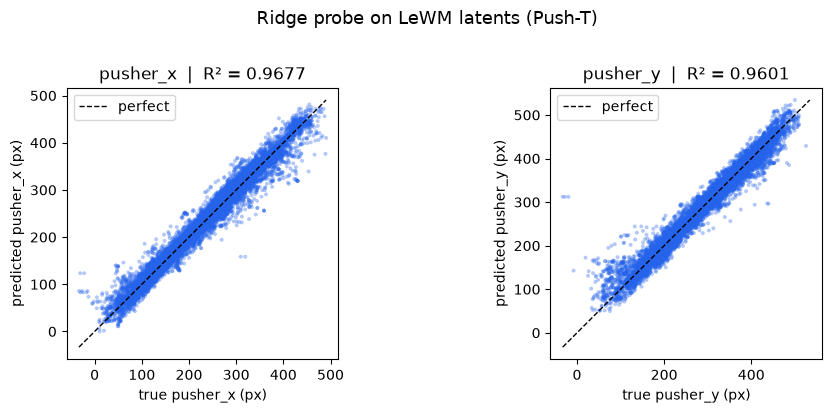

In [9]:
pusher_probe = Ridge(alpha=1.0).fit(Z_train, Y_train)

Y_pred = pusher_probe.predict(Z_test)

r2 = r2_score(Y_test, Y_pred) #How well do the predicted block coords match the real
r2_x = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_y = r2_score(Y_test[:, 1], Y_pred[:, 1])
rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))
rmse_x = np.sqrt(np.mean((Y_test[:, 0] - Y_pred[:, 0]) ** 2))
rmse_y = np.sqrt(np.mean((Y_test[:, 1] - Y_pred[:, 1]) ** 2))

print("Linear probe: LeWM latents → block (x, y)")
print(f"  samples : {len(Y_test):,} test / {len(Y_train):,} train")
print(f"  alpha   : {pusher_probe.alpha}")
print(f"  R²      : {r2:.4f}  (x: {r2_x:.4f}, y: {r2_y:.4f})")
print(f"  RMSE    : {rmse:.2f} px  (x: {rmse_x:.2f}, y: {rmse_y:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, dim, name, r2_dim in zip(
    axes, [0, 1], ["pusher_x", "pusher_y"], [r2_x, r2_y]
):
    ax.scatter(Y_test[:, dim], Y_pred[:, dim], s=8, alpha=0.35, c="#2563eb", edgecolors="none")
    lo = min(Y_test[:, dim].min(), Y_pred[:, dim].min())
    hi = max(Y_test[:, dim].max(), Y_pred[:, dim].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    ax.set_xlabel(f"true {name} (px)")
    ax.set_ylabel(f"predicted {name} (px)")
    ax.set_title(f"{name}  |  R² = {r2_dim:.4f}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

fig.suptitle("Ridge probe on LeWM latents (Push-T)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Testing the Avoidance

## Imports

In [10]:
import gymnasium as gym
from sklearn import preprocessing
from stable_worldmodel.solver import CEMSolver
from IPython.display import display
import importlib
import helpers.linProbeHelpers as lph

importlib.reload(lph)
from helpers.linProbeHelpers import *

## Helpers

In [11]:
pixel_prep = get_img_preprocessor("pixels", "pixels", img_size=224)
goal_prep  = get_img_preprocessor("goal", "goal", img_size=224)

transform = {
    "pixels": wm_transform(pixel_prep, "pixels"),
    "goal":   wm_transform(goal_prep, "goal"),
}

## Creating the custom test state

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


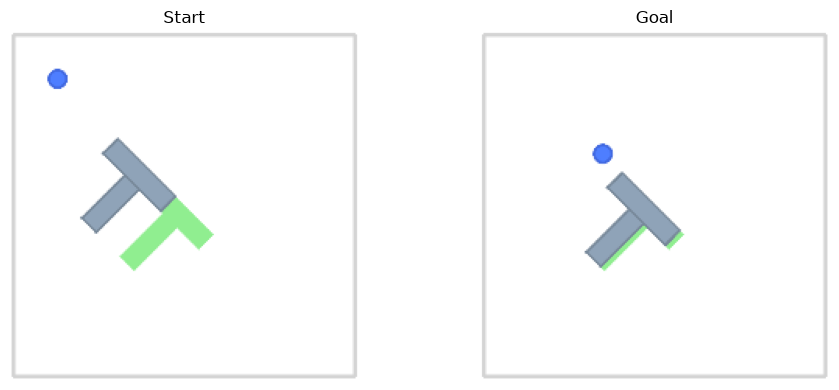

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [12]:
start_state = make_pusht_state(
    pusher_xy=(70, 70),    # just above/right of block — tune visually
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)

goal_state = make_pusht_state(
    pusher_xy=(180, 180),    # near goal block too (success checks both)
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(start_state, goal_state)

In [13]:
# Unfortunatley LeWM doesn't take in the raw env data so we need to build out the normalisation dict
dataset = swm.data.HDF5Dataset(
    path=str(H5_PATH),  
    keys_to_cache=["action", "proprio", "state"],
)
process = {}
for col in ["action", "proprio", "state"]:
    proc = preprocessing.StandardScaler()
    data = dataset.get_col_data(col)
    data = data[~np.isnan(data).any(axis=1)]
    proc.fit(data)
    process[col] = proc
    if col != "action":
        process[f"goal_{col}"] = proc

20:49:15 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


20:49:15 | INFO  | __init__.py | Cached 'proprio' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


20:49:15 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


## Loading in the Model and Planner

In [14]:
#We init the same params as LeWM
model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
plan_config = swm.PlanConfig(
    horizon=5, #Plans 5 decision steps/latent actions
    receding_horizon=5, #Executing all 5 before re planning
    action_block=5)

solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9935 seconds


CEM solve time: 0.9024 seconds


success: True
final state: [ 182.8639979   193.69891938  255.23630479  247.99006861    0.71241992
   -0.57963359 -103.9830246 ]
goal state:  [180.         180.         250.         250.           0.78539816
   0.           0.        ]
steps: 50
20:49:19 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


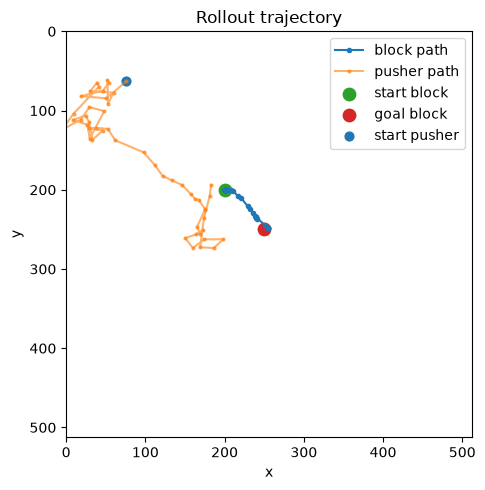

In [15]:
# --- world + custom reset ---
EVAL_BUDGET = 50  # same as le-wm pusht eval
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []

world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)
states = np.stack(states)  # (T, 7)
success = bool(world.terminateds[0])
print("success:", success)
print("final state:", states[-1])
print("goal state: ", goal_state)
print("steps:", len(frames))

display(animate_frames(frames, interval_ms=100))
plot_trajectory(states, start_state, goal_state)

## Testing it out with the Hazard

## Setting up the Hazard env

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


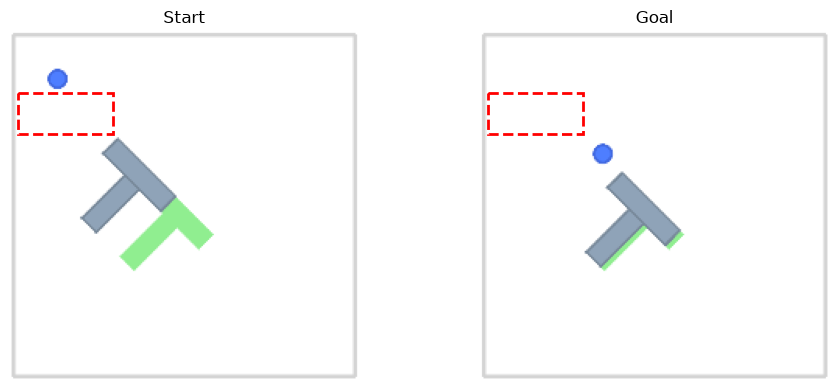

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [16]:
# Corridor box between start block (200,200) and goal (250,250)
hazard_box = (10.0, 150.0, 90.0, 150.0)  # (x_min, x_max, y_min, y_max) near top-left

start_state = make_pusht_state(
    pusher_xy=(70, 70),
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)
goal_state = make_pusht_state(
    pusher_xy=(180, 180),
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(start_state, goal_state, hazard_box=hazard_box)

CEM solve time: 0.9451 seconds


CEM solve time: 0.9109 seconds



CEM solve 1
  first: goal median=403.119, hazard max=5.357, hazard nonzero=0.027
  final: goal median=294.004, hazard max=0.000, hazard nonzero=0.000

CEM solve 2
  first: goal median=412.623, hazard max=2.139, hazard nonzero=0.003
  final: goal median=72.913, hazard max=0.000, hazard nonzero=0.000
Last CEM iteration cost scales
goal:   min=14.5161, median=72.9134, max=351.1537
hazard: min=0.0000, median=0.0000, max=0.0000
λ·hazard: min=0.0000, median=0.0000, max=0.0000
nonzero hazard fraction: 0.0
λ=1.0
success: True
violation: {'any_violation': True, 'n_violating_steps': 16, 'frac_violating': 0.32}
final block xy: [258.91833711 238.13825406]
goal block xy: [250. 250.]
20:49:23 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


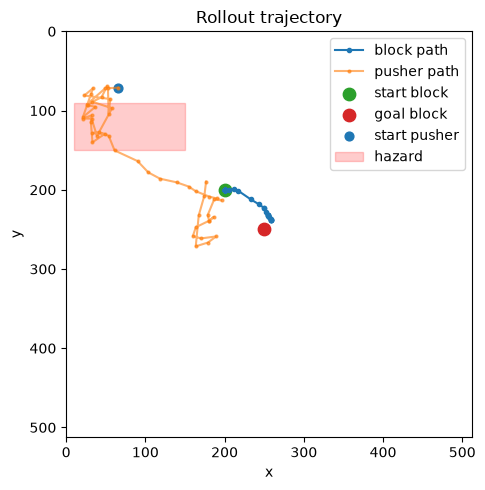

In [17]:
LAM = 1.0  # try 0 first (= baseline), then 1e-2, 1e-1, 1, 10, 100, ...

base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
model = HazardAugmentedCostModel(
    base_model, pusher_probe, hazard_box, lam=LAM
).to("cuda").eval()

plan_config = swm.PlanConfig(horizon=5, receding_horizon=5, action_block=5)
solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

EVAL_BUDGET = 50
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []
world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)

solve_diagnostics = summarize_cem_history(model)

goal_costs = model.last_goal_cost.float()
hazard_costs = model.last_hazard_cost.float()
weighted_hazard = LAM * hazard_costs

print("Last CEM iteration cost scales")
print(
    f"goal:   min={goal_costs.min():.4f}, "
    f"median={goal_costs.median():.4f}, "
    f"max={goal_costs.max():.4f}"
)
print(
    f"hazard: min={hazard_costs.min():.4f}, "
    f"median={hazard_costs.median():.4f}, "
    f"max={hazard_costs.max():.4f}"
)
print(
    f"λ·hazard: min={weighted_hazard.min():.4f}, "
    f"median={weighted_hazard.median():.4f}, "
    f"max={weighted_hazard.max():.4f}"
)
print(
    "nonzero hazard fraction:",
    (hazard_costs > 0).float().mean().item(),
)

states = np.stack(states)
success = bool(world.terminateds[0])
viol = real_violation_stats(states, hazard_box, entity="pusher")

print(f"λ={LAM}")
print("success:", success)
print("violation:", viol)
print("final block xy:", states[-1, 2:4])
print("goal block xy:", goal_state[2:4])

display(animate_frames(frames, interval_ms=100))
plot_trajectory(states, start_state, goal_state, hazard_box=hazard_box)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9161 seconds


CEM solve time: 0.9176 seconds


λ=0        success=True viol=0.28 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


...

λ=10       success=False viol=0.30 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9166 seconds


CEM solve time: 0.9143 seconds


λ=100      success=True viol=0.31 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


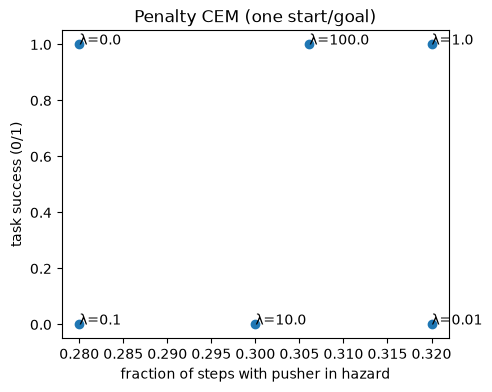

In [18]:
def run_hazard_episode(lam, seed=0):
    base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
    cost_model = HazardAugmentedCostModel(
        base_model, pusher_probe, hazard_box, lam=lam
    ).to("cuda").eval()

    solver = CEMSolver(
        model=cost_model,
        batch_size=1,
        num_samples=300,
        var_scale=1.0,
        n_steps=30,
        topk=30,
        device="cuda",
        seed=seed,
    )
    policy = swm.policy.WorldModelPolicy(
        solver=solver,
        config=swm.PlanConfig(horizon=5, receding_horizon=5, action_block=5),
        process=process,
        transform=transform,
    )
    world = swm.World(
        "swm/PushT-v1",
        num_envs=1,
        image_shape=(224, 224),
        max_episode_steps=100,
    )
    world.set_policy(policy)
    world.reset(seed=seed, options={"state": start_state, "goal_state": goal_state})

    frames, states = [], []
    world._run(max_steps=50, mode="wait", on_step=make_on_step(frames, states))
    solve_diagnostics = summarize_cem_history(
        cost_model,
        verbose=False,
    )
    goal_costs = cost_model.last_goal_cost.float()
    hazard_costs = cost_model.last_hazard_cost.float()
    weighted_hazard = lam * hazard_costs
    
    cost_diagnostics = {
        "goal_min": goal_costs.min().item(),
        "goal_median": goal_costs.median().item(),
        "goal_max": goal_costs.max().item(),
        "hazard_min": hazard_costs.min().item(),
        "hazard_median": hazard_costs.median().item(),
        "hazard_max": hazard_costs.max().item(),
        "weighted_hazard_median": weighted_hazard.median().item(),
        "nonzero_hazard_fraction": (
            (hazard_costs > 0).float().mean().item()
        ),
        "solve_diagnostics": solve_diagnostics,
    }
    
    states = np.stack(states)
    viol = real_violation_stats(states, hazard_box)
    return {
        "lam": lam,
        "success": bool(world.terminateds[0]),
        **viol,
        **cost_diagnostics,
        "states": states,
        "frames": frames,
    }


results = []
for lam in [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]:
    r = run_hazard_episode(lam)
    results.append(r)

    solve1 = r["solve_diagnostics"][0]

    print(
        f"λ={lam:<8g} "
        f"success={r['success']} "
        f"viol={r['frac_violating']:.2f} "
        f"solve1 initial hazard max={solve1['first_hazard_max']:.2f} "
        f"solve1 final hazard max={solve1['final_hazard_max']:.2f} "
        f"final nonzero={solve1['final_hazard_nonzero']:.2f}"
    )

# quick Pareto view
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    [r["frac_violating"] for r in results],
    [float(r["success"]) for r in results],
)
for r in results:
    ax.annotate(f"λ={r['lam']}", (r["frac_violating"], float(r["success"])))
ax.set_xlabel("fraction of steps with pusher in hazard")
ax.set_ylabel("task success (0/1)")
ax.set_title("Penalty CEM (one start/goal)")
plt.show()

## Agent test: hazard uncertainty margin and replanning

This isolated sweep keeps the true hazard fixed for evaluation while varying the expanded planning hazard, penalty weight, and MPC receding horizon.

In [19]:
def expand_hazard_box(box, margin):
    x0, x1, y0, y1 = box
    return (
        max(0.0, x0 - margin),
        min(512.0, x1 + margin),
        max(0.0, y0 - margin),
        min(512.0, y1 + margin),
    )


def run_margin_episode(lam, margin, receding_horizon, seed=0):
    planning_box = expand_hazard_box(hazard_box, margin)

    base = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
    base.requires_grad_(False)
    cost_model = HazardAugmentedCostModel(
        base, pusher_probe, planning_box, lam=lam
    ).to("cuda").eval()

    solver = CEMSolver(
        model=cost_model,
        batch_size=1,
        num_samples=300,
        var_scale=1.0,
        n_steps=30,
        topk=30,
        device="cuda",
        seed=seed,
    )
    policy = swm.policy.WorldModelPolicy(
        solver=solver,
        config=swm.PlanConfig(
            horizon=5,
            receding_horizon=receding_horizon,
            action_block=5,
        ),
        process=process,
        transform=transform,
    )

    test_world = swm.World(
        "swm/PushT-v1",
        num_envs=1,
        image_shape=(224, 224),
        max_episode_steps=100,
    )
    test_world.set_policy(policy)
    test_world.reset(
        seed=seed,
        options={"state": start_state, "goal_state": goal_state},
    )

    test_frames, test_states = [], []
    test_world._run(
        max_steps=50,
        mode="wait",
        on_step=make_on_step(test_frames, test_states),
    )
    test_states = np.stack(test_states)

    real_violation = real_violation_stats(
        test_states, hazard_box, entity="pusher"
    )
    sampled_violation = real_violation_stats(
        test_states[4::5], hazard_box, entity="pusher"
    )
    solves = summarize_cem_history(cost_model, verbose=False)

    result = {
        "lam": lam,
        "margin": margin,
        "receding_horizon": receding_horizon,
        "planning_box": planning_box,
        "success": bool(test_world.terminateds[0]),
        **real_violation,
        "sampled_violation": sampled_violation["frac_violating"],
        "num_solves": len(solves),
        "solve1_initial_hazard_max": solves[0]["first_hazard_max"],
        "solve1_initial_hazard_nonzero": solves[0]["first_hazard_nonzero"],
        "solve1_final_hazard_max": solves[0]["final_hazard_max"],
        "solve1_final_hazard_nonzero": solves[0]["final_hazard_nonzero"],
        "states": test_states,
    }
    test_world.close()
    return result


TEST_CASES = [
    # Baseline and original hard-box penalty.
    {"lam": 0.0, "margin": 0.0, "receding_horizon": 5},
    {"lam": 1.0, "margin": 0.0, "receding_horizon": 5},
    # Isolate uncertainty-margin effects under the paper's MPC schedule.
    {"lam": 1.0, "margin": 10.0, "receding_horizon": 5},
    {"lam": 1.0, "margin": 20.0, "receding_horizon": 5},
    {"lam": 10.0, "margin": 20.0, "receding_horizon": 5},
    # Replan every latent step to reduce open-loop model error.
    {"lam": 1.0, "margin": 20.0, "receding_horizon": 1},
    {"lam": 10.0, "margin": 20.0, "receding_horizon": 1},
    {"lam": 100.0, "margin": 20.0, "receding_horizon": 1},
]

margin_results = []
for case in TEST_CASES:
    result = run_margin_episode(**case)
    margin_results.append(result)
    print(
        f"lambda={result['lam']:<6g} margin={result['margin']:<4g} "
        f"RH={result['receding_horizon']} success={result['success']} "
        f"violation={result['frac_violating']:.2f} "
        f"sampled={result['sampled_violation']:.2f} "
        f"solve1 initial nz={result['solve1_initial_hazard_nonzero']:.2f} "
        f"final nz={result['solve1_final_hazard_nonzero']:.2f} "
        f"final max={result['solve1_final_hazard_max']:.2f}"
    )

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9131 seconds


CEM solve time: 0.9130 seconds


lambda=0      margin=0    RH=5 success=True violation=0.28 sampled=0.30 solve1 initial nz=0.03 final nz=0.00 final max=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


...

CEM solve time: 0.9138 seconds


CEM solve time: 0.9141 seconds


CEM solve time: 0.9143 seconds


CEM solve time: 0.9157 seconds


CEM solve time: 0.9145 seconds
lambda=100    margin=20   RH=1 success=False violation=0.36 sampled=0.30 solve1 initial nz=0.62 final nz=0.02 final max=10.62


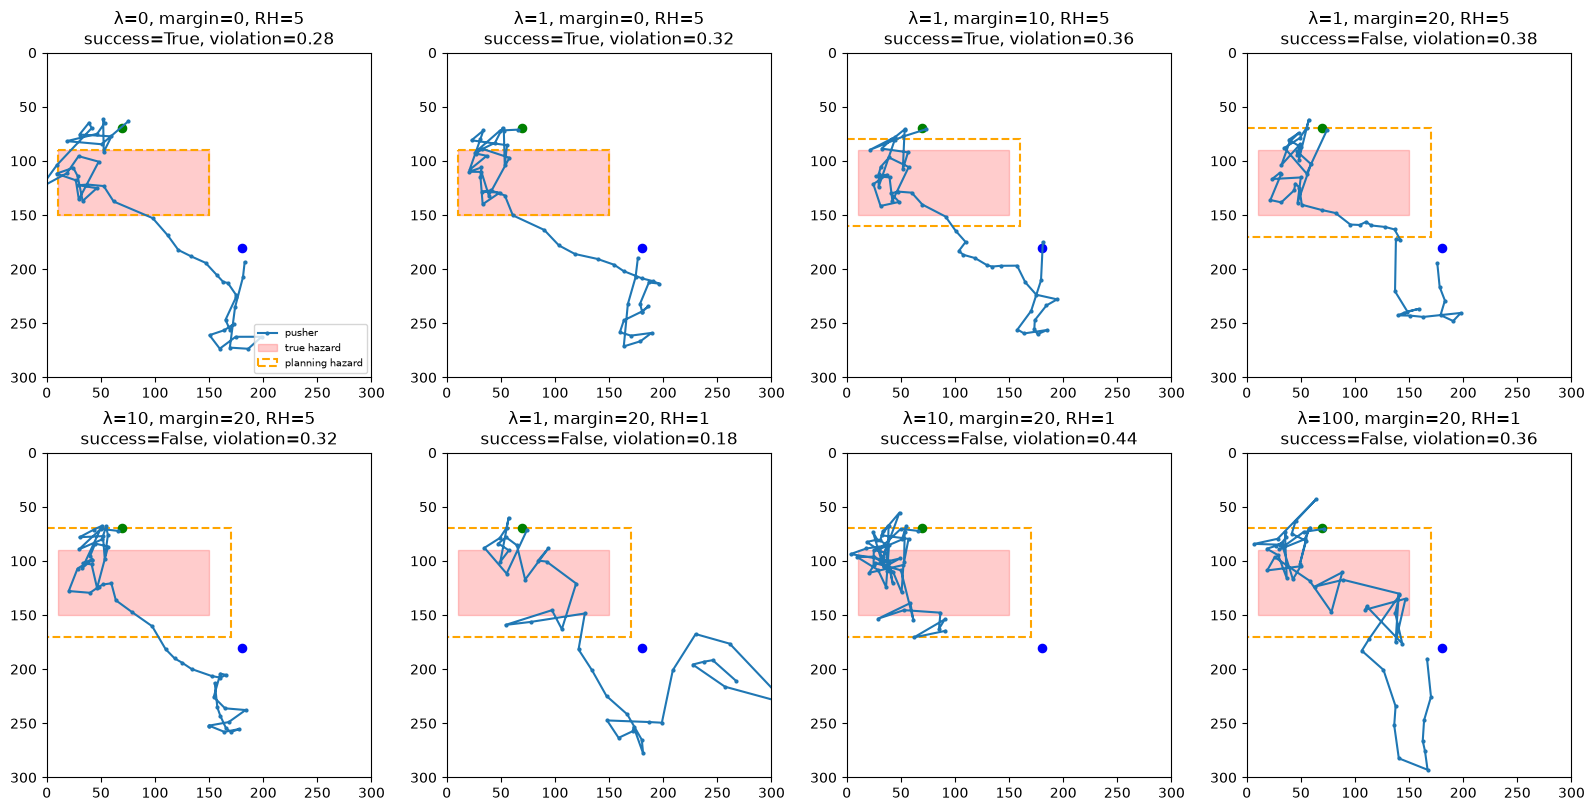

In [20]:
from matplotlib.patches import Rectangle

n = len(margin_results)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for ax, result in zip(axes.flat, margin_results):
    xy = result["states"][:, :2]
    ax.plot(xy[:, 0], xy[:, 1], "o-", ms=2, label="pusher")

    x0, x1, y0, y1 = hazard_box
    ax.add_patch(Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        color="red", alpha=0.2, label="true hazard",
    ))

    px0, px1, py0, py1 = result["planning_box"]
    ax.add_patch(Rectangle(
        (px0, py0), px1 - px0, py1 - py0,
        fill=False, edgecolor="orange", linestyle="--",
        linewidth=1.5, label="planning hazard",
    ))

    ax.scatter(start_state[0], start_state[1], color="green", s=35)
    ax.scatter(goal_state[0], goal_state[1], color="blue", s=35)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 300)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(
        f"λ={result['lam']:g}, margin={result['margin']:g}, "
        f"RH={result['receding_horizon']}\n"
        f"success={result['success']}, violation={result['frac_violating']:.2f}"
    )

for ax in axes.flat[n:]:
    ax.axis("off")

axes.flat[0].legend(loc="lower right", fontsize=7)
plt.show()

In [21]:
# Targeted follow-up: isolate replanning itself and search below lambda=1.
TARGETED_CASES = [
    {"lam": 0.0, "margin": 0.0, "receding_horizon": 1},
    {"lam": 0.01, "margin": 20.0, "receding_horizon": 1},
    {"lam": 0.03, "margin": 20.0, "receding_horizon": 1},
    {"lam": 0.1, "margin": 20.0, "receding_horizon": 1},
    {"lam": 0.3, "margin": 20.0, "receding_horizon": 1},
]

targeted_results = []
for case in TARGETED_CASES:
    result = run_margin_episode(**case)
    targeted_results.append(result)
    print(
        f"lambda={result['lam']:<6g} margin={result['margin']:<4g} "
        f"RH={result['receding_horizon']} success={result['success']} "
        f"violation={result['frac_violating']:.2f} "
        f"sampled={result['sampled_violation']:.2f} "
        f"solve1 initial nz={result['solve1_initial_hazard_nonzero']:.2f} "
        f"final nz={result['solve1_final_hazard_nonzero']:.2f} "
        f"final max={result['solve1_final_hazard_max']:.2f}"
    )

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9126 seconds


CEM solve time: 0.9158 seconds


CEM solve time: 0.9143 seconds


CEM solve time: 0.9158 seconds


...

CEM solve time: 0.9171 seconds


CEM solve time: 0.9171 seconds


CEM solve time: 0.9168 seconds


CEM solve time: 0.9169 seconds


CEM solve time: 0.9689 seconds
lambda=0.3    margin=20   RH=1 success=True violation=0.24 sampled=0.14 solve1 initial nz=0.62 final nz=0.00 final max=0.00
